# Predicting Employee Attrition Using HR Analytics

### A Data-Driven Approach to Workforce Retention

Jimmy (Ka Ian) Ji  
King's College London — BA Philosophy

This project involves using python with editing suggestions from Chatgpt as an assisting data anlysis tool to analyse an HR employee dataset and identify the key drivers of employee attrition and build a predictive model capable of estimating attrition risk. The analysis combines exploratory data analysis, statistical testing, and logistic regression modelling to generate actionable human resource insights.

# Executive Summary

This project investigates the drivers of employee attrition using HR analytics and predictive modelling. The objective was to identify the most influential factors associated with employee turnover and demonstrate how organisations can use data-driven methods to inform retention strategies.

Key findings from the analysis include:

• **Overtime** is the strongest predictor of attrition, suggesting that sustained workload pressure significantly increases turnover risk.

• Employees who have gone longer without **promotion** show higher attrition probability, indicating the importance of career progression pathways.

• **Job satisfaction and workplace environment satisfaction** strongly reduce attrition risk, highlighting the role of organisational culture.

• The predictive model successfully identified employees at elevated risk of leaving, enabling the segmentation of employees into **low, medium, and high-risk groups**.

Overall, the results demonstrate how predictive analytics can support proactive human resource management and improve workforce stability.

# HR Attrition Analytics Project

## Contents
1. **Introduction**  
2. Dataset Overview  
3. Data Preparation  
4. Exploratory Analysis  
5. Statistical Validation  
6. Predictive Modelling  
7. Model Evaluation  
8. Key Predictors of Attrition  
9. Risk Segmentation  
10. **Strategic HR Implications**  
11. **Final Evaluation and Conclusion**
12. **Improvement Simulator**
13. Additional Charts

## Project Objective

Employee attrition represents a major organisational challenge. High turnover can increase recruitment costs, reduce team stability, and negatively affect organisational performance.

The objective of this project is to:

1. Identify the key factors associated with employee attrition  
2. Validate these relationships using statistical testing  
3. Build a predictive model estimating the probability of attrition  
4. Segment employees by attrition risk  
5. Derive strategic recommendations for improving employee retention

## Dataset

The dataset used in this analysis contains employee records including demographic, job-related, and organisational variables. The data includes information such as:

• Job satisfaction  
• Monthly income  
• Years at the company  
• Overtime workload  
• Promotion history  
• Manager relationships  

The dataset contains **1470 employee observations and 35 variables**.

The target variable is **Attrition**, indicating whether an employee left the organisation.

## Project Workflow

The analysis follows a structured analytics pipeline:

1. Data preparation and cleaning  
2. Exploratory analysis of attrition patterns  
3. Statistical testing of key relationships  
4. Logistic regression modelling  
5. Risk segmentation based on predicted probabilities  
6. Strategic interpretation of results

# 1. Data Preparation


In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

# 2. Exploratory Analysis


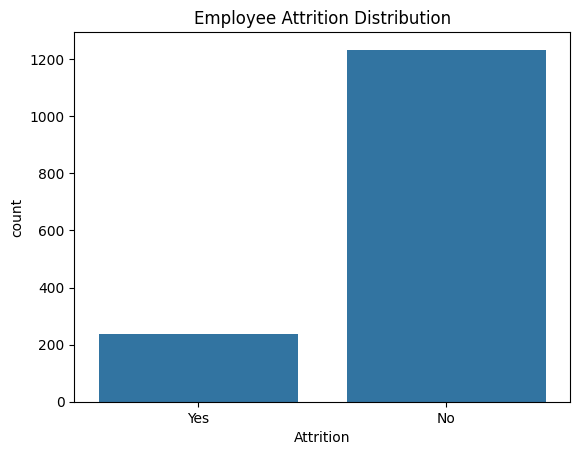

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)

plt.title("Employee Attrition Distribution")
plt.show()

## Attrition vs Overtime Analysis

Overtime is often associated with employee burnout. 
This section examines whether employees working overtime 
are more likely to leave the company.

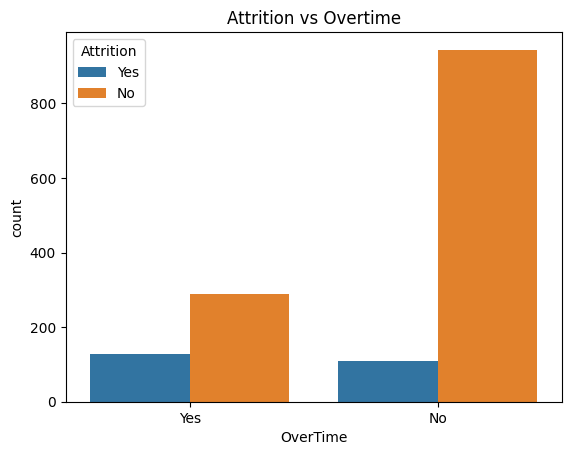

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("Attrition vs Overtime")
plt.show()

In [8]:
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')


## Attrition vs Income / Job Satisfaction / Time at Company

Overtime is often associated with Pay,Satisfaction at work,and how long employees have served in the company. 
This section examines whether these factors 
matter to attrition decisions.

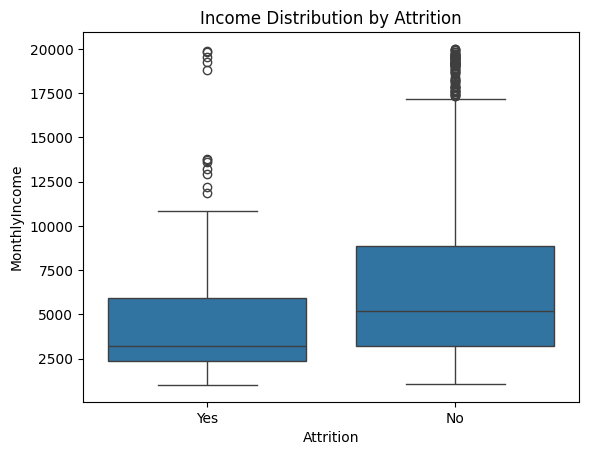

In [9]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title("Income Distribution by Attrition")
plt.show()

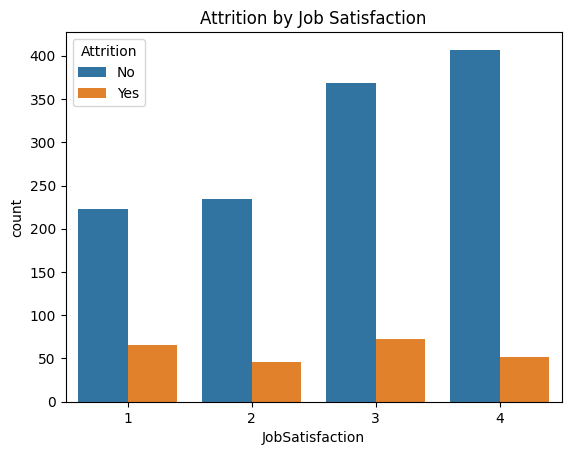

In [10]:
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)

plt.title("Attrition by Job Satisfaction")
plt.show()

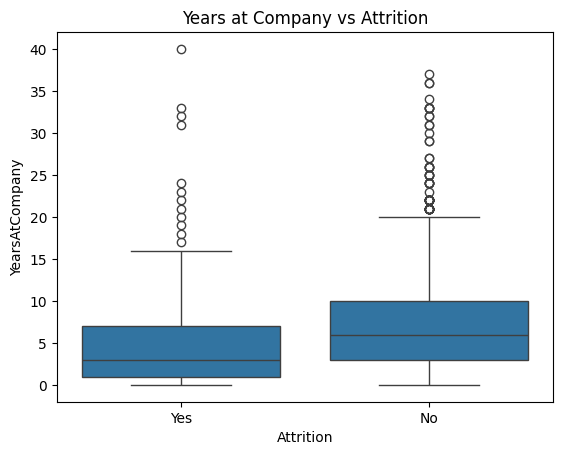

In [11]:
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)

plt.title("Years at Company vs Attrition")
plt.show()

## Summary table

We now tie all these factros together to see which ones matters most. I will additionally use: 	
Mutual Information for influence strength / Spearman correlation for direction (whether higher values tend to go with more or less attrition)

In [12]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import spearmanr


# 1. Copy dataset
df_analysis = df.copy()

# 2. Encode target variable
df_analysis["Attrition_Binary"] = df_analysis["Attrition"].map({"No": 0, "Yes": 1})

# 3. Select factors to compare
factors = [
    "OverTime",
    "MonthlyIncome",
    "JobSatisfaction",
    "YearsAtCompany",
    "YearsSinceLastPromotion"
]

# 4. Encode variables where needed
df_analysis["OverTime"] = df_analysis["OverTime"].map({"No": 0, "Yes": 1})

# Keep only needed columns
analysis_df = df_analysis[factors + ["Attrition_Binary"]].copy()


# 5. Define which variables are discrete
# True = categorical/ordinal-like
discrete_flags = [True, False, True, False, False]

X = analysis_df[factors]
y = analysis_df["Attrition_Binary"]

# 6. Compute Mutual Information
mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_flags,
    random_state=42
)

# 7. Compute Spearman correlations
correlations = []
p_values = []

for factor in factors:
    corr, pval = spearmanr(analysis_df[factor], y)
    correlations.append(corr)
    p_values.append(pval)

# 8. Build summary table
results = pd.DataFrame({
    "Factor": factors,
    "Mutual_Information": mi_scores,
    "Spearman_Correlation": correlations,
    "P_Value": p_values
})

# Absolute correlation for easier interpretation
results["Abs_Correlation"] = results["Spearman_Correlation"].abs()

# Direction label
results["Direction"] = results["Spearman_Correlation"].apply(
    lambda x: "Higher value → Higher attrition" if x > 0 else "Higher value → Lower attrition"
)

# Rank by influence
results = results.sort_values(by="Mutual_Information", ascending=False).reset_index(drop=True)
results["Influence_Rank"] = results.index + 1

# Reorder columns nicely
results = results[
    [
        "Influence_Rank",
        "Factor",
        "Mutual_Information",
        "Spearman_Correlation",
        "Abs_Correlation",
        "P_Value",
        "Direction"
    ]
]

results

,Influence_Rank,Factor,Mutual_Information,Spearman_Correlation,Abs_Correlation,P_Value,Direction
0,1,MonthlyIncome,0.031970,-0.198305,0.198305,1.680405e-14,Higher value → Lower attrition
1,2,OverTime,0.027688,0.246118,0.246118,1.009254e-21,Higher value → Higher attrition
2,3,YearsAtCompany,0.022083,-0.190419,0.190419,1.811379e-13,Higher value → Lower attrition
3,4,JobSatisfaction,0.005904,-0.102948,0.102948,7.677639e-05,Higher value → Lower attrition
4,5,YearsSinceLastPromotion,0.000000,-0.053273,0.053273,4.113005e-02,Higher value → Lower attrition


In [13]:
results.style.format({
    "Mutual_Information": "{:.4f}",
    "Spearman_Correlation": "{:.4f}",
    "Abs_Correlation": "{:.4f}",
    "P_Value": "{:.4f}"
})

,Influence_Rank,Factor,Mutual_Information,Spearman_Correlation,Abs_Correlation,P_Value,Direction
0,1,MonthlyIncome,0.0320,-0.1983,0.1983,0.0000,Higher value → Lower attrition
1,2,OverTime,0.0277,0.2461,0.2461,0.0000,Higher value → Higher attrition
2,3,YearsAtCompany,0.0221,-0.1904,0.1904,0.0000,Higher value → Lower attrition
3,4,JobSatisfaction,0.0059,-0.1029,0.1029,0.0001,Higher value → Lower attrition
4,5,YearsSinceLastPromotion,0.0000,-0.0533,0.0533,0.0411,Higher value → Lower attrition


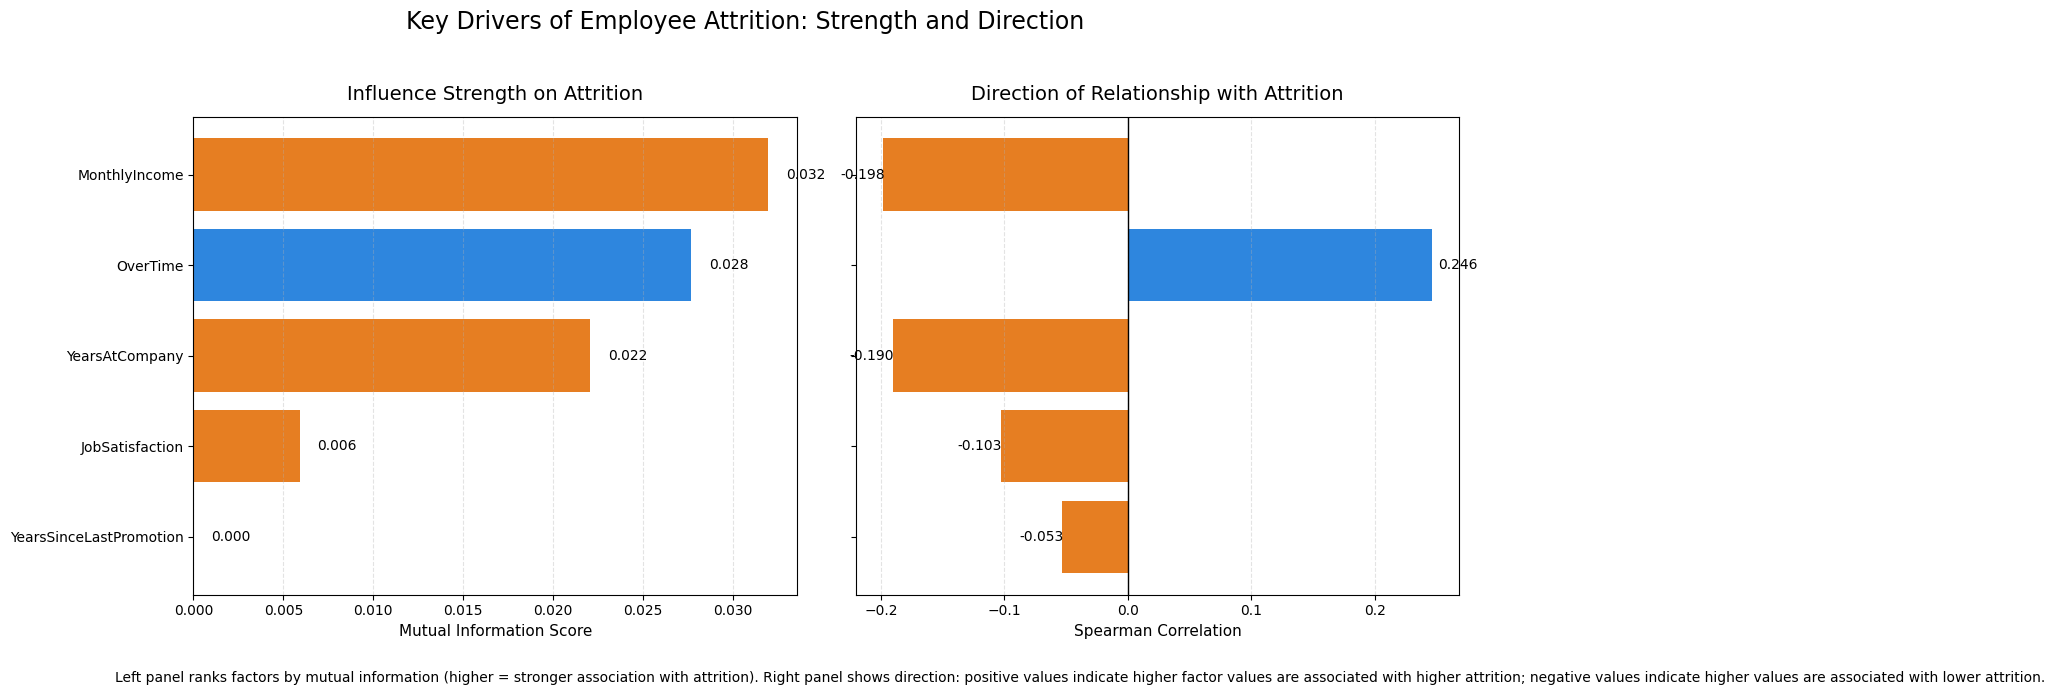

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Sort for plotting (highest influence at top in final display)
plot_df = results.copy().sort_values("Mutual_Information", ascending=True)

# Colors for direction
bar_colors = plot_df["Spearman_Correlation"].apply(
    lambda x: "#2E86DE" if x > 0 else "#E67E22"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# ----------------------------
# LEFT PANEL: Mutual Information
# ----------------------------
bars1 = axes[0].barh(
    plot_df["Factor"],
    plot_df["Mutual_Information"],
    color=bar_colors
)

axes[0].set_title("Influence Strength on Attrition", fontsize=14, pad=12)
axes[0].set_xlabel("Mutual Information Score", fontsize=11)
axes[0].grid(axis="x", linestyle="--", alpha=0.35)

# Add labels to MI bars
for bar in bars1:
    width = bar.get_width()
    axes[0].text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

# ----------------------------
# RIGHT PANEL: Spearman Correlation
# ----------------------------
bars2 = axes[1].barh(
    plot_df["Factor"],
    plot_df["Spearman_Correlation"],
    color=bar_colors
)

axes[1].set_title("Direction of Relationship with Attrition", fontsize=14, pad=12)
axes[1].set_xlabel("Spearman Correlation", fontsize=11)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].grid(axis="x", linestyle="--", alpha=0.35)

# Add labels to correlation bars
for bar in bars2:
    width = bar.get_width()
    x_pos = width + 0.005 if width >= 0 else width - 0.035
    axes[1].text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

# ----------------------------
# Overall title and note
# ----------------------------
fig.suptitle(
    "Key Drivers of Employee Attrition: Strength and Direction",
    fontsize=17,
    y=0.98
)

fig.text(
    0.08,
    0.02,
    "Left panel ranks factors by mutual information (higher = stronger association with attrition). "
    "Right panel shows direction: positive values indicate higher factor values are associated with higher attrition; "
    "negative values indicate higher values are associated with lower attrition.",
    ha="left",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

# 3. Statistical Validation


## Chi-Squared tests and T-tests

It is always important not just to evaluate the data to form conclusions, but to also evaluate the conclusions to see whether they are trustworthy

In [15]:
from scipy.stats import chi2_contingency

# overtime vs attrition
table = pd.crosstab(df['OverTime'], df['Attrition'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 87.56429365828768
p-value: 8.15842372153832e-21


In [16]:
table = pd.crosstab(df['JobSatisfaction'], df['Attrition'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 17.505077010348
p-value: 0.0005563004510387556


In [17]:
from scipy.stats import ttest_ind

stay = df[df["Attrition"] == "No"]["MonthlyIncome"]
leave = df[df["Attrition"] == "Yes"]["MonthlyIncome"]

t, p = ttest_ind(stay, leave)

print("t-statistic:", t)
print("p-value:", p)

t-statistic: 6.203935765608938
p-value: 7.147363985353811e-10


## Statistics Validated

All tested variables produced p-values below the conventional significance threshold (p < 0.05). This indicates that the relationships observed in the earlier visualisations and correlation analysis are statistically significant.

In particular, the overtime test yielded an extremely small p-value (≈ 8.15 × 10⁻²¹), providing very strong evidence that employees working overtime are significantly more likely to leave the company.

Taken together, these statistical tests support the conclusions drawn in the previous analysis: factors such as overtime workload, compensation level, job satisfaction, tenure, and promotion history are meaningfully associated with employee attrition in this dataset.

# 4. Predictive Modelling


## Predictive Modelling of Employee Attrition

After identifying and statistically validating several factors associated with employee attrition, the next step is to build a predictive model.

Logistic regression was selected because attrition is a binary outcome (employees either leave or remain). The model estimates the probability that an employee leaves the company based on multiple explanatory variables.

This approach allows us to identify which factors most strongly influence attrition and to estimate the likelihood of attrition for individual employees.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_model = df.copy()

# Encode target variable
df_model["Attrition"] = df_model["Attrition"].map({"No": 0, "Yes": 1})

# Encode categorical predictors
categorical_cols = df_model.select_dtypes(include="object").columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Define features and target
X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

model_pipeline.fit(X_train, y_train)

print("Scaled logistic regression model trained successfully.")

X shape: (1470, 34)
y shape: (1470,)
Training set: (1176, 34) (1176,)
Test set: (294, 34) (294,)
Scaled logistic regression model trained successfully.


In [19]:
predictions = model_pipeline.predict(X_test)
probabilities = model_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", round(accuracy, 4))

Model Accuracy: 0.8741


In [20]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



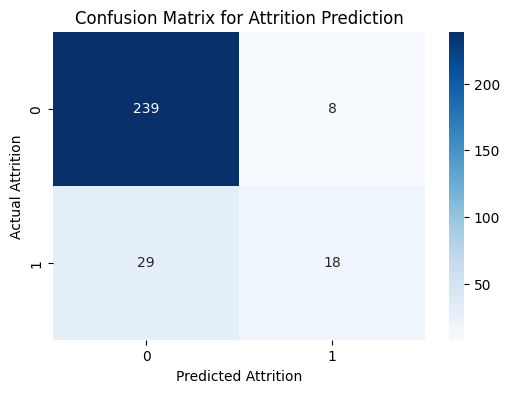

In [21]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Attrition Prediction")
plt.xlabel("Predicted Attrition")
plt.ylabel("Actual Attrition")
plt.show()

In [22]:
logreg_model = model_pipeline.named_steps["logreg"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute_Coefficient", ascending=False)

coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
21,OverTime,0.782163,0.782163
32,YearsSinceLastPromotion,0.481498,0.481498
3,Department,0.470444,0.470444
19,NumCompaniesWorked,0.449615,0.449615
33,YearsWithCurrManager,-0.437533,0.437533
9,EnvironmentSatisfaction,-0.437171,0.437171
27,TotalWorkingYears,-0.418747,0.418747
0,Age,-0.410156,0.410156
15,JobSatisfaction,-0.381713,0.381713
31,YearsInCurrentRole,-0.359704,0.359704


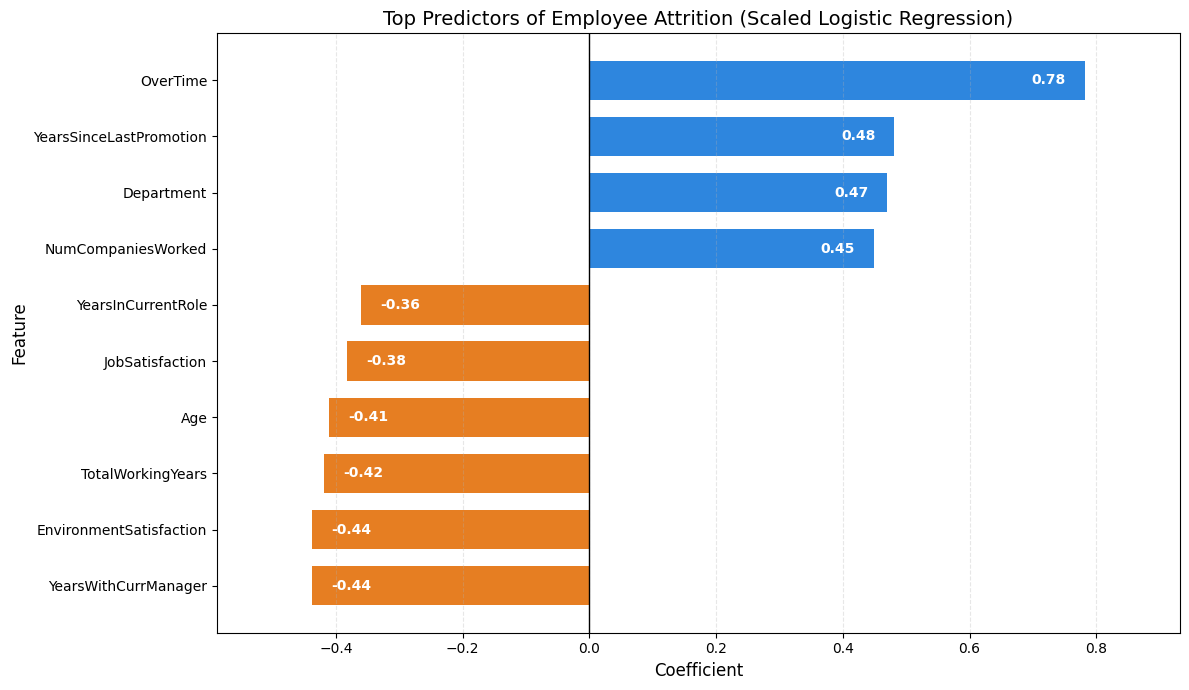

In [23]:
top_features = coefficients.head(10).sort_values("Coefficient", ascending=True)

plt.figure(figsize=(12, 7))

colors = top_features["Coefficient"].apply(
    lambda x: "#2E86DE" if x > 0 else "#E67E22"
)

bars = plt.barh(
    top_features["Feature"],
    top_features["Coefficient"],
    color=colors,
    height=0.7
)

# Add labels more intelligently
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    # Positive bars
    if width > 0:
        if width > 0.12:
            # Put label inside bar
            plt.text(
                width - 0.03,
                y,
                f"{width:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                color="white",
                fontweight="bold"
            )
        else:
            # Put label outside bar
            plt.text(
                width + 0.03,
                y,
                f"{width:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                color="black"
            )

    # Negative bars
    else:
        if width < -0.12:
            # Put label inside bar
            plt.text(
                width + 0.03,
                y,
                f"{width:.2f}",
                va="center",
                ha="left",
                fontsize=10,
                color="white",
                fontweight="bold"
            )
        else:
            # Put label outside bar
            plt.text(
                width - 0.03,
                y,
                f"{width:.2f}",
                va="center",
                ha="right",
                fontsize=10,
                color="black"
            )

plt.axvline(0, color="black", linewidth=1)

plt.title("Top Predictors of Employee Attrition (Scaled Logistic Regression)", fontsize=14)
plt.xlabel("Coefficient", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Give more breathing room on both sides
plt.xlim(top_features["Coefficient"].min() - 0.15, top_features["Coefficient"].max() + 0.15)

plt.tight_layout()
plt.show()

# 5. Attrition Risk Segmentation

In [24]:
risk_df = X_test.copy()
risk_df["Actual_Attrition"] = y_test.values
risk_df["Predicted_Attrition"] = predictions
risk_df["Attrition_Probability"] = probabilities

risk_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Actual_Attrition,Predicted_Attrition,Attrition_Probability
1061,24,0,830,2,13,2,1,1,1495,4,...,1,2,3,1,0,0,0,0,0,0.170025
891,44,2,1117,1,2,1,1,1,1246,1,...,10,5,3,10,5,7,7,0,0,0.008113
456,31,2,688,2,7,3,1,1,613,3,...,10,3,2,5,4,0,1,0,0,0.211294
922,44,2,1199,1,4,2,1,1,1288,3,...,26,4,2,25,9,14,13,0,0,0.002312
69,36,2,318,1,9,3,3,1,90,4,...,2,0,2,1,0,0,0,1,0,0.469979


In [25]:
def risk_category(p):
    if p >= 0.70:
        return "High"
    elif p >= 0.40:
        return "Medium"
    else:
        return "Low"

risk_df["Risk_Level"] = risk_df["Attrition_Probability"].apply(risk_category)

risk_df[["Attrition_Probability", "Risk_Level", "Actual_Attrition", "Predicted_Attrition"]].head(10)

,Attrition_Probability,Risk_Level,Actual_Attrition,Predicted_Attrition
1061,0.170025,Low,0,0
891,0.008113,Low,0,0
456,0.211294,Low,0,0
922,0.002312,Low,0,0
69,0.469979,Medium,1,0
1164,0.290408,Low,0,0
406,0.020885,Low,0,0
1330,0.010416,Low,0,0
1232,0.009569,Low,0,0
1311,0.350075,Low,0,0


Risk_Level
Low       254
Medium     28
High       12
Name: count, dtype: int64


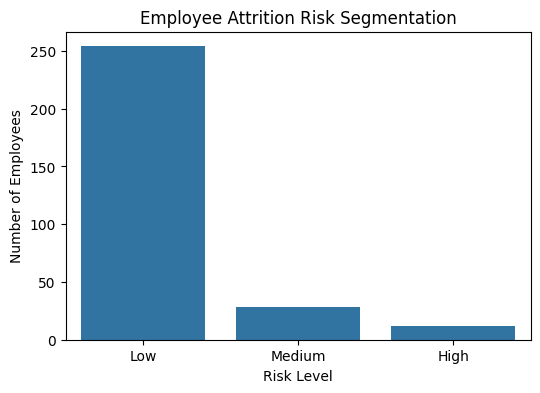

In [26]:
risk_summary = risk_df["Risk_Level"].value_counts().reindex(["Low", "Medium", "High"])

print(risk_summary)

plt.figure(figsize=(6, 4))
sns.countplot(x="Risk_Level", data=risk_df, order=["Low", "Medium", "High"])
plt.title("Employee Attrition Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")
plt.show()

# 6. Key Predictors of Attrition


In [27]:

# Project Summary Cell

import pandas as pd
import numpy as np

# 1. Basic dataset summary
n_rows, n_cols = df.shape
attrition_rate = df["Attrition"].value_counts(normalize=True).get("Yes", 0)

# 2. Model accuracy
model_accuracy = accuracy

# 3. Top predictors
top_positive = (
    coefficients.sort_values("Coefficient", ascending=False)
    .head(5)[["Feature", "Coefficient"]]
    .reset_index(drop=True)
)

top_negative = (
    coefficients.sort_values("Coefficient", ascending=True)
    .head(5)[["Feature", "Coefficient"]]
    .reset_index(drop=True)
)

# 4. Risk segmentation
risk_counts = risk_df["Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0).astype(int)

# 5. Average predicted attrition probability
avg_risk = risk_df["Attrition_Probability"].mean()

# 6. Highest-risk employees in test set
highest_risk = (
    risk_df[["Attrition_Probability", "Risk_Level", "Actual_Attrition", "Predicted_Attrition"]]
    .sort_values("Attrition_Probability", ascending=False)
    .head(10)
    .reset_index()
)

# 7. Print clean summary
print("===== HR ATTRITION PROJECT SUMMARY =====\n")

print(f"Dataset size: {n_rows} rows x {n_cols} columns")
print(f"Overall attrition rate: {attrition_rate:.2%}")
print(f"Model accuracy: {model_accuracy:.2%}")
print(f"Average predicted attrition probability (test set): {avg_risk:.2%}\n")

print("Risk segmentation:")
for level, count in risk_counts.items():
    print(f"  {level}: {count}")

print("\nTop 5 predictors increasing attrition risk:")
for i, row in top_positive.iterrows():
    print(f"  {i+1}. {row['Feature']} ({row['Coefficient']:.3f})")

print("\nTop 5 predictors reducing attrition risk:")
for i, row in top_negative.iterrows():
    print(f"  {i+1}. {row['Feature']} ({row['Coefficient']:.3f})")

print("\nTop 10 highest-risk employees in the test set:")
display(highest_risk)

print("\nTop positive predictors table:")
display(top_positive)

print("\nTop negative predictors table:")
display(top_negative)

print("\nRisk segmentation table:")
display(risk_counts.reset_index().rename(columns={"index": "Risk_Level", "Risk_Level": "Count"}))

===== HR ATTRITION PROJECT SUMMARY =====

Dataset size: 1470 rows x 35 columns
Overall attrition rate: 16.12%
Model accuracy: 87.41%
Average predicted attrition probability (test set): 16.59%

Risk segmentation:
  Low: 254
  Medium: 28
  High: 12

Top 5 predictors increasing attrition risk:
  1. OverTime (0.782)
  2. YearsSinceLastPromotion (0.481)
  3. Department (0.470)
  4. NumCompaniesWorked (0.450)
  5. DistanceFromHome (0.314)

Top 5 predictors reducing attrition risk:
  1. YearsWithCurrManager (-0.438)
  2. EnvironmentSatisfaction (-0.437)
  3. TotalWorkingYears (-0.419)
  4. Age (-0.410)
  5. JobSatisfaction (-0.382)

Top 10 highest-risk employees in the test set:


,index,Attrition_Probability,Risk_Level,Actual_Attrition,Predicted_Attrition
0,688,0.890194,High,1,1
1,911,0.875729,High,1,1
2,762,0.843696,High,1,1
3,132,0.841935,High,1,1
4,357,0.832330,High,1,1
5,709,0.831032,High,1,1
6,1021,0.818716,High,1,1
7,525,0.777221,High,1,1
8,514,0.744681,High,1,1
9,711,0.733621,High,1,1



Top positive predictors table:


,Feature,Coefficient
0,OverTime,0.782163
1,YearsSinceLastPromotion,0.481498
2,Department,0.470444
3,NumCompaniesWorked,0.449615
4,DistanceFromHome,0.313663



Top negative predictors table:


,Feature,Coefficient
0,YearsWithCurrManager,-0.437533
1,EnvironmentSatisfaction,-0.437171
2,TotalWorkingYears,-0.418747
3,Age,-0.410156
4,JobSatisfaction,-0.381713



Risk segmentation table:


,Count,count
0,Low,254
1,Medium,28
2,High,12


## Model Performance

A logistic regression model was trained to estimate the probability that an employee will leave the organisation. The dataset was split into training and testing sets using an 80/20 split to evaluate the model on unseen data.

The model achieved an accuracy of **87.41%**, indicating that it correctly classified the majority of employee attrition outcomes.

While accuracy alone does not capture all aspects of model performance, it suggests that the model is capable of identifying patterns associated with employee turnover in the dataset.

The confusion matrix and classification report provide additional detail on prediction performance across employees who stayed and those who left.

## Key Predictors of Employee Attrition

Analysis of the logistic regression coefficients identified several variables that strongly influence the likelihood of employee attrition.

The strongest predictors associated with **higher attrition probability** include:

• OverTime  
• YearsSinceLastPromotion  
• NumCompaniesWorked  

These variables suggest that workload intensity, delayed career progression, and prior job mobility contribute to increased turnover risk.

Conversely, several variables were associated with **lower attrition probability**, including:

• JobSatisfaction  
• EnvironmentSatisfaction  
• YearsWithCurrManager  

These factors highlight the importance of workplace satisfaction and stable managerial relationships in retaining employees.

## Employee Risk Segmentation

Using the predicted probabilities from the logistic regression model, employees in the test set were classified into three risk categories:

• **Low Risk** – predicted attrition probability below 40%  
• **Medium Risk** – predicted probability between 40% and 70%  
• **High Risk** – predicted probability above 70%

This segmentation allows organisations to identify employees who may require proactive retention strategies.

The distribution of employees across these risk categories illustrates how predictive analytics can help prioritise human resource interventions.

# 7. Strategic HR Implications


## Strategic Human Resource Implications

The findings of this analysis suggest several potential strategies for improving employee retention.

### Workload Management
Overtime was the strongest predictor of attrition. Sustained overtime demands may lead to burnout and reduced job satisfaction. Organisations should monitor overtime exposure and consider workload balancing or additional support mechanisms.

### Career Progression
Employees who had gone longer without promotion showed higher attrition risk. Establishing clearer promotion pathways and transparent career development opportunities may reduce turnover.

### Employee Engagement
Higher job satisfaction and environment satisfaction were associated with lower attrition risk. Initiatives aimed at improving workplace culture, recognition, and employee engagement may therefore play a significant role in retention.

### Managerial Relationships
Employees with longer tenure under the same manager were less likely to leave. This suggests that strong managerial relationships may improve employee commitment and organisational stability.

# 8. Final Evaluation and Conclusion

## Limitations

While the analysis provides useful insights into employee attrition patterns, several limitations should be noted.

• The dataset represents a single organisational context and may not generalise across industries.

• Some potentially relevant factors (e.g., employee engagement surveys, organisational culture indicators) are not included in the dataset.

• Logistic regression provides interpretable relationships but may not capture complex nonlinear patterns present in workforce behaviour.

Future research could extend the analysis using additional datasets or more advanced modelling techniques such as ensemble methods.

## Future Work

Future improvements to this project could include:

• Implementing more advanced predictive models (e.g., Random Forest or Gradient Boosting)

• Building a fully interactive HR analytics dashboard for organisational decision-makers

• Incorporating time-series employee data to study attrition trends over time

• Developing a decision-support tool that recommends targeted retention strategies based on predicted attrition risk

## Conclusion

This project demonstrates how data analytics can be applied to understand and predict employee attrition. Through exploratory analysis, statistical testing, and predictive modelling, several key factors influencing employee turnover were identified.

The results illustrate how HR data can be transformed into actionable insights, supporting more informed workforce management decisions.

More broadly, the project highlights the potential of data-driven approaches to improve organisational effectiveness and employee retention.

## Retention Strategy Simulation

To evaluate how organisational policies might influence employee turnover, a simple scenario simulation was conducted.

The simulation models the potential impact of several HR interventions:

• Reduction of employee overtime  
• Increased job satisfaction  
• Faster promotion timelines  

The logistic regression model was then used to estimate attrition probabilities under this hypothetical scenario.

Results suggest that these interventions could reduce the average attrition probability across employees, illustrating how predictive analytics can support proactive retention strategies.

In [28]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Start from original dataset
df_model = df.copy()

# Encode target
df_model["Attrition"] = df_model["Attrition"].map({"No": 0, "Yes": 1})

# Encode all categorical columns
categorical_cols = df_model.select_dtypes(include="object").columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

df_model.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [29]:
X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 34)
y shape: (1470,)


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_scaled, y)

print("Scaler and model fitted successfully.")

Scaler and model fitted successfully.


In [31]:
current_prob = model.predict_proba(X_scaled)[:, 1]

df_model["Current_Attrition_Prob"] = current_prob

df_model["Current_Attrition_Prob"].describe()

count    1470.000000
mean        0.161190
std         0.191692
min         0.000170
25%         0.026592
50%         0.084126
75%         0.218873
max         0.952384
Name: Current_Attrition_Prob, dtype: float64

In [32]:
simulation_df = df_model.copy()

# Simulated interventions
# OverTime: 0 = No, 1 = Yes in the encoded version
simulation_df["OverTime"] = 0

# Increase satisfaction by 1 point, capped at 4
simulation_df["JobSatisfaction"] = simulation_df["JobSatisfaction"].clip(upper=3) + 1

# Reduce years since last promotion by 1, minimum 0
simulation_df["YearsSinceLastPromotion"] = (
    simulation_df["YearsSinceLastPromotion"] - 1
).clip(lower=0)

simulation_df[["OverTime", "JobSatisfaction", "YearsSinceLastPromotion"]].head()

,OverTime,JobSatisfaction,YearsSinceLastPromotion
0,0,4,0
1,0,3,0
2,0,4,0
3,0,4,2
4,0,3,1


In [33]:
X_sim = simulation_df.drop(columns=["Attrition", "Current_Attrition_Prob"], errors="ignore")

X_sim_scaled = scaler.transform(X_sim)

sim_prob = model.predict_proba(X_sim_scaled)[:, 1]

simulation_df["Simulated_Attrition_Prob"] = sim_prob

simulation_df[["Simulated_Attrition_Prob"]].head()

,Simulated_Attrition_Prob
0,0.281914
1,0.009171
2,0.166760
3,0.017861
4,0.316951


In [34]:
comparison = pd.DataFrame({
    "Current_Risk": df_model["Current_Attrition_Prob"],
    "Simulated_Risk": simulation_df["Simulated_Attrition_Prob"]
})

comparison["Risk_Reduction"] = comparison["Current_Risk"] - comparison["Simulated_Risk"]

comparison.head()

,Current_Risk,Simulated_Risk,Risk_Reduction
0,0.701490,0.281914,0.419576
1,0.015502,0.009171,0.006330
2,0.635974,0.166760,0.469214
3,0.156245,0.017861,0.138384
4,0.441143,0.316951,0.124192


In [35]:
avg_current = comparison["Current_Risk"].mean()
avg_sim = comparison["Simulated_Risk"].mean()

risk_reduction = avg_current - avg_sim

print("Average attrition probability (current):", round(avg_current, 4))
print("Average attrition probability (after HR improvements):", round(avg_sim, 4))
print("Estimated reduction:", round(risk_reduction, 4))

Average attrition probability (current): 0.1612
Average attrition probability (after HR improvements): 0.0777
Estimated reduction: 0.0835


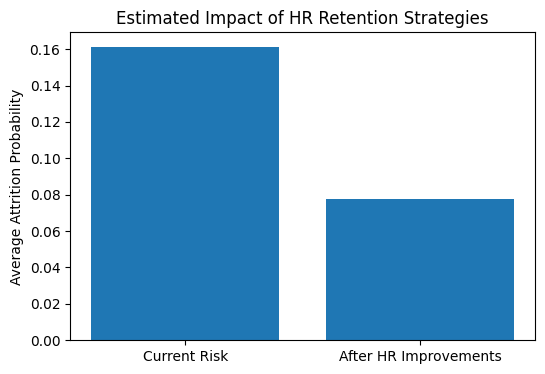

In [36]:
import matplotlib.pyplot as plt

values = [avg_current, avg_sim]
labels = ["Current Risk", "After HR Improvements"]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Average Attrition Probability")
plt.title("Estimated Impact of HR Retention Strategies")
plt.show()

## Retention Strategy Simulation Results

To evaluate the potential impact of HR interventions, a scenario simulation was conducted using the trained logistic regression model.

Three hypothetical improvements were applied:

• removal of overtime requirements  
• increased job satisfaction by one level where possible  
• faster promotion timelines (reducing years since last promotion)

Under the baseline model, the average predicted attrition probability across employees was **16.1%**.

Under the simulated HR policy scenario, the predicted attrition probability decreased to **7.8%**.

This corresponds to an estimated reduction of **8.35 percentage points**, representing a **~52% reduction in predicted attrition risk**.

While this simulation represents a simplified scenario, the results illustrate how targeted improvements in working conditions and career progression opportunities could meaningfully influence employee retention.

More broadly, this exercise demonstrates how predictive analytics can be used not only to identify attrition drivers but also to evaluate the potential impact of organisational policies.

# Additional Graphs and Charts

In [37]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Overall attrition rate
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

# Risk segmentation counts
risk_counts = risk_df["Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)

# Overtime attrition table
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").reset_index()
overtime_attrition["Attrition_Yes"] = overtime_attrition["Yes"] * 100

# Job satisfaction attrition table
jobsat_attrition = pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index").reset_index()
jobsat_attrition["Attrition_Yes"] = jobsat_attrition["Yes"] * 100

# Top predictors for dashboard
top_predictors = coefficients.head(8).copy()
top_predictors = top_predictors.sort_values("Coefficient", ascending=True)

# Probability distribution
prob_df = risk_df.copy()

In [38]:
fig_kpi = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
    horizontal_spacing=0.12
)

fig_kpi.add_trace(
    go.Indicator(
        mode="number",
        value=attrition_rate,
        number={"suffix": "%"},
        title={"text": "Overall Attrition Rate"}
    ),
    row=1, col=1
)

fig_kpi.add_trace(
    go.Indicator(
        mode="number",
        value=risk_counts["High"],
        title={"text": "High-Risk Employees<br>(Test Set)"}
    ),
    row=1, col=2
)

fig_kpi.add_trace(
    go.Indicator(
        mode="number",
        value=accuracy * 100,
        number={"suffix": "%"},
        title={"text": "Model Accuracy"}
    ),
    row=1, col=3
)

fig_kpi.update_layout(
    title="HR Attrition Dashboard — Key Metrics",
    height=250,
    margin=dict(t=60, b=20, l=20, r=20)
)

fig_kpi.show()

In [39]:
fig_risk = px.bar(
    x=risk_counts.index,
    y=risk_counts.values,
    color=risk_counts.index,
    title="Employee Risk Segmentation",
    labels={"x": "Risk Level", "y": "Number of Employees"}
)

fig_risk.update_layout(showlegend=False)
fig_risk.show()

In [40]:
fig_pred = px.bar(
    top_predictors,
    x="Coefficient",
    y="Feature",
    orientation="h",
    color="Coefficient",
    color_continuous_scale="RdBu",
    title="Top Predictors of Employee Attrition"
)

fig_pred.update_layout(yaxis_title="Feature", xaxis_title="Coefficient")
fig_pred.show()

In [41]:
fig_overtime = px.bar(
    overtime_attrition,
    x="OverTime",
    y="Attrition_Yes",
    color="OverTime",
    title="Attrition Rate by Overtime Status",
    labels={"Attrition_Yes": "Attrition Rate (%)"}
)

fig_overtime.update_layout(showlegend=False)
fig_overtime.show()

In [42]:
fig_jobsat = px.line(
    jobsat_attrition,
    x="JobSatisfaction",
    y="Attrition_Yes",
    markers=True,
    title="Attrition Rate by Job Satisfaction",
    labels={"Attrition_Yes": "Attrition Rate (%)"}
)

fig_jobsat.show()

In [43]:
fig_prob = px.histogram(
    prob_df,
    x="Attrition_Probability",
    nbins=20,
    title="Distribution of Predicted Attrition Probabilities",
    labels={"Attrition_Probability": "Predicted Attrition Probability"}
)

fig_prob.show()